# Lab 2.2 — Attenuation + Reflection Analysis (Real Data)

Setup modeled here:
- ZFSC-2-372+ splitter
- Port `S` -> SDR / power meter
- Port `1` -> injected RF signal
- Port `2` -> open-ended cable stub (one-way length `L`) producing reflections

This notebook compares:
1. Linear attenuation model `y = B - alpha*L`
2. Reflection-aware model `y = B - alpha*L + A*cos(kL + phi)`

The known ~8 m anomaly is excluded from fitting.


In [1]:
import csv
import math
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (9, 4.8)
plt.rcParams['axes.grid'] = True

# Linear model bootstrap can be large because it is cheap.
BOOTSTRAP_LINEAR_N = 10_000
# Ripple bootstrap is costlier (k scan each resample), keep practical.
BOOTSTRAP_RIPPLE_N = 1_000
BOOTSTRAP_SEED = 121

POWER_REL_DIFF_TOL = 1e-6
EXCLUDE_LENGTHS_M = [7.9248]
EXCLUDE_LENGTH_TOL_M = 0.05
ATTENUATOR_DB = 13.0

K_PERIOD_MIN_M = 0.20
K_PERIOD_MAX_M = 20.0
K_GRID_N = 300

C_LIGHT = 299_792_458.0

REQUIRED_COLUMNS = [
    'set_id', 'cable_length_m', 'power_meter_dbm',
    'lo1420_path', 'lo1421_path',
    'lo1420_total_power', 'lo1421_total_power',
]

FILENAME_PATTERN = re.compile(r'ATTEN-set(?P<set_id>\d+)-LO(?P<lo_mhz>\d+)-L(?P<len_tag>[0-9mp]+)m_cal_')


In [2]:
def find_repo_root(start: Path | None = None) -> Path:
    if start is None:
        start = Path.cwd().resolve()
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'labs' / '02').exists() and (candidate / 'ugradiolab').exists():
            return candidate
    raise RuntimeError('Could not locate repository root from current working directory.')


def format_length_tag(length_m: float) -> str:
    return f'{length_m:.3f}'.replace('-', 'm').replace('.', 'p')


def resolve_data_path(raw_path: str, repo_root: Path) -> Path:
    p = Path(raw_path)
    if p.is_absolute() and p.exists():
        return p
    if p.exists():
        return p.resolve()
    candidate = (repo_root / p).resolve()
    if candidate.exists():
        return candidate
    raise FileNotFoundError(f'Could not resolve data path: {raw_path!r}')


def read_manifest(manifest_path: Path) -> list[dict]:
    if not manifest_path.exists():
        raise FileNotFoundError(f'Manifest not found: {manifest_path}')
    if manifest_path.stat().st_size == 0:
        raise ValueError(f'Manifest is empty: {manifest_path}')

    with manifest_path.open('r', newline='') as handle:
        reader = csv.DictReader(handle)
        if reader.fieldnames is None:
            raise ValueError('Manifest has no header row.')
        missing = [c for c in REQUIRED_COLUMNS if c not in reader.fieldnames]
        if missing:
            raise ValueError(f'Manifest missing required columns: {missing}')
        rows = list(reader)

    if not rows:
        raise ValueError('Manifest contains zero data rows.')
    return rows


def coerce_and_validate_rows(rows: list[dict], repo_root: Path) -> list[dict]:
    parsed = []
    for i, row in enumerate(rows, start=1):
        try:
            set_id = int(row['set_id'])
            length_m = float(row['cable_length_m'])
            meter_dbm = float(row['power_meter_dbm'])
            p1420 = float(row['lo1420_total_power'])
            p1421 = float(row['lo1421_total_power'])
        except Exception as exc:
            raise ValueError(f'Row {i} type conversion failed: {exc}') from exc

        if length_m < 0:
            raise ValueError(f'Row {i}: cable_length_m must be non-negative, got {length_m}')
        if p1420 <= 0 or p1421 <= 0:
            raise ValueError(f'Row {i}: total powers must be > 0, got {p1420}, {p1421}')

        lo1420_path = resolve_data_path(row['lo1420_path'], repo_root)
        lo1421_path = resolve_data_path(row['lo1421_path'], repo_root)
        for p in (lo1420_path, lo1421_path):
            if p.stat().st_size <= 0:
                raise ValueError(f'Row {i}: file is empty: {p}')

        m0 = FILENAME_PATTERN.search(lo1420_path.name)
        m1 = FILENAME_PATTERN.search(lo1421_path.name)
        if m0 is None or m1 is None:
            raise ValueError(f'Row {i}: filename pattern mismatch for set files.')
        if int(m0.group("set_id")) != set_id or int(m1.group("set_id")) != set_id:
            raise ValueError(f'Row {i}: set_id mismatch between manifest and filename.')
        if int(m0.group("lo_mhz")) != 1420 or int(m1.group("lo_mhz")) != 1421:
            raise ValueError(f'Row {i}: expected LO1420/LO1421 filenames.')

        expected_tag = format_length_tag(length_m)
        length_tag_ok = (m0.group("len_tag") == expected_tag and m1.group("len_tag") == expected_tag)

        parsed.append({
            'set_id': set_id,
            'cable_length_m': length_m,
            'power_meter_dbm': meter_dbm,
            'siggen_freq_mhz': float(row.get('siggen_freq_mhz', np.nan)),
            'siggen_amp_dbm': float(row.get('siggen_amp_dbm', np.nan)),
            'lo1420_path': lo1420_path,
            'lo1421_path': lo1421_path,
            'lo1420_total_power_manifest': p1420,
            'lo1421_total_power_manifest': p1421,
            'length_tag_ok': length_tag_ok,
        })

    if len(parsed) < 2:
        raise ValueError('Need at least 2 sets for fitting.')
    if len({r["cable_length_m"] for r in parsed}) < 2:
        raise ValueError('Need at least 2 unique cable lengths for slope fitting.')
    return parsed


def is_excluded_length(length_m: float) -> bool:
    return any(abs(length_m - x) <= EXCLUDE_LENGTH_TOL_M for x in EXCLUDE_LENGTHS_M)


def safe_quantiles(samples: np.ndarray, probs=(0.16, 0.5, 0.84)):
    if samples.size == 0:
        return np.array([np.nan] * len(probs), dtype=float)
    return np.quantile(samples, probs)


def aic_bic_from_rss(rss: float, n_obs: int, n_params: int) -> tuple[float, float]:
    if not np.isfinite(rss) or rss <= 0 or n_obs <= n_params:
        return np.nan, np.nan
    aic = n_obs * np.log(rss / n_obs) + 2 * n_params
    bic = n_obs * np.log(rss / n_obs) + n_params * np.log(n_obs)
    return float(aic), float(bic)


In [3]:
REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / 'data' / 'lab02' / 'attenuation'
MANIFEST_PATH = DATA_DIR / 'manifest.csv'
RAW_DIR = DATA_DIR / 'raw'

print('Repository root:', REPO_ROOT)
print('Data directory  :', DATA_DIR)
print('Manifest        :', MANIFEST_PATH)
print('Raw directory   :', RAW_DIR)

rows_raw = read_manifest(MANIFEST_PATH)
rows = coerce_and_validate_rows(rows_raw, REPO_ROOT)

print(f'Loaded {len(rows)} sets before exclusion.')
dup = {}
for r in rows:
    dup[r["cable_length_m"]] = dup.get(r["cable_length_m"], 0) + 1
print("Repeated lengths before exclusion:", {k:v for k,v in dup.items() if v>1} or "none")

bad_tags = [r for r in rows if not r["length_tag_ok"]]
if bad_tags:
    print(f'WARNING: {len(bad_tags)} rows have filename length-tag mismatch.')

excluded_rows = [r for r in rows if is_excluded_length(r["cable_length_m"])]
rows = [r for r in rows if not is_excluded_length(r["cable_length_m"])]

if excluded_rows:
    print('Excluded anomaly set_ids:', [r['set_id'] for r in excluded_rows])
    print('Excluded anomaly lengths [m]:', sorted({r['cable_length_m'] for r in excluded_rows}))
else:
    print('No anomaly rows matched exclusion criteria.')

if len(rows) < 2 or len({r["cable_length_m"] for r in rows}) < 2:
    raise ValueError('Not enough data after exclusion to fit attenuation.')

print(f'Using {len(rows)} sets after exclusion.')


Repository root: /Users/junruiting/GitHub/ay-121
Data directory  : /Users/junruiting/GitHub/ay-121/data/lab02/attenuation
Manifest        : /Users/junruiting/GitHub/ay-121/data/lab02/attenuation/manifest.csv
Raw directory   : /Users/junruiting/GitHub/ay-121/data/lab02/attenuation/raw
Loaded 9 sets before exclusion.
Repeated lengths before exclusion: {0.6223: 2, 1.8288: 2}
Excluded anomaly set_ids: [7]
Excluded anomaly lengths [m]: [7.9248]
Using 8 sets after exclusion.


In [4]:
def try_recompute_total_power(path: Path):
    try:
        # Raw files may not be parseable as npz on all runs.
        from ugradiolab import Spectrum
        return float(Spectrum.from_data(path).total_power), None
    except Exception as exc:
        return None, exc


recompute_errors = []
for r in rows:
    p0, e0 = try_recompute_total_power(r["lo1420_path"])
    p1, e1 = try_recompute_total_power(r["lo1421_path"])
    r["lo1420_total_power_recomputed"] = p0
    r["lo1421_total_power_recomputed"] = p1
    if e0 is not None:
        recompute_errors.append((r["set_id"], 1420, r["lo1420_path"], e0))
    if e1 is not None:
        recompute_errors.append((r["set_id"], 1421, r["lo1421_path"], e1))

if recompute_errors:
    print(f'WARNING: failed raw recompute for {len(recompute_errors)} LO files; using manifest totals.')
    for set_id, lo, path, err in recompute_errors[:6]:
        print(f'  set {set_id:04d} LO{lo}: {type(err).__name__}: {err}')
    use_recomputed = False
else:
    rel = []
    for r in rows:
        rel.append(abs(r["lo1420_total_power_recomputed"] - r["lo1420_total_power_manifest"]) / r["lo1420_total_power_manifest"])
        rel.append(abs(r["lo1421_total_power_recomputed"] - r["lo1421_total_power_manifest"]) / r["lo1421_total_power_manifest"])
    max_rel = max(rel) if rel else 0.0
    print(f'Max rel diff manifest vs raw recompute: {max_rel:.3e}')
    use_recomputed = max_rel > POWER_REL_DIFF_TOL
    print('Using recomputed totals:', use_recomputed)

for r in rows:
    r["lo1420_total_power"] = r["lo1420_total_power_recomputed"] if use_recomputed else r["lo1420_total_power_manifest"]
    r["lo1421_total_power"] = r["lo1421_total_power_recomputed"] if use_recomputed else r["lo1421_total_power_manifest"]

rows = sorted(rows, key=lambda x: (x["cable_length_m"], x["set_id"]))
L = np.array([r["cable_length_m"] for r in rows], dtype=float)
meter_dbm = np.array([r["power_meter_dbm"] for r in rows], dtype=float)
p1420 = np.array([r["lo1420_total_power"] for r in rows], dtype=float)
p1421 = np.array([r["lo1421_total_power"] for r in rows], dtype=float)
y1420_db = 10.0 * np.log10(p1420)
y1421_db = 10.0 * np.log10(p1421)
ratio_db = y1420_db - y1421_db
siggen_freq_hz = float(np.nanmedian([r["siggen_freq_mhz"] for r in rows])) * 1e6

print('N sets used:', len(rows))
print('Length range [m]:', float(L.min()), 'to', float(L.max()))
print('Manual meter range [dBm]:', float(meter_dbm.min()), 'to', float(meter_dbm.max()))
print('Siggen frequency [MHz]:', siggen_freq_hz / 1e6)


/Users/junruiting/GitHub/ay-121/.venv/lib/python3.14/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Max rel diff manifest vs raw recompute: 0.000e+00
Using recomputed totals: False
N sets used: 8
Length range [m]: 0.254 to 1.8288
Manual meter range [dBm]: -6.9 to -0.53
Siggen frequency [MHz]: 1420.405751768


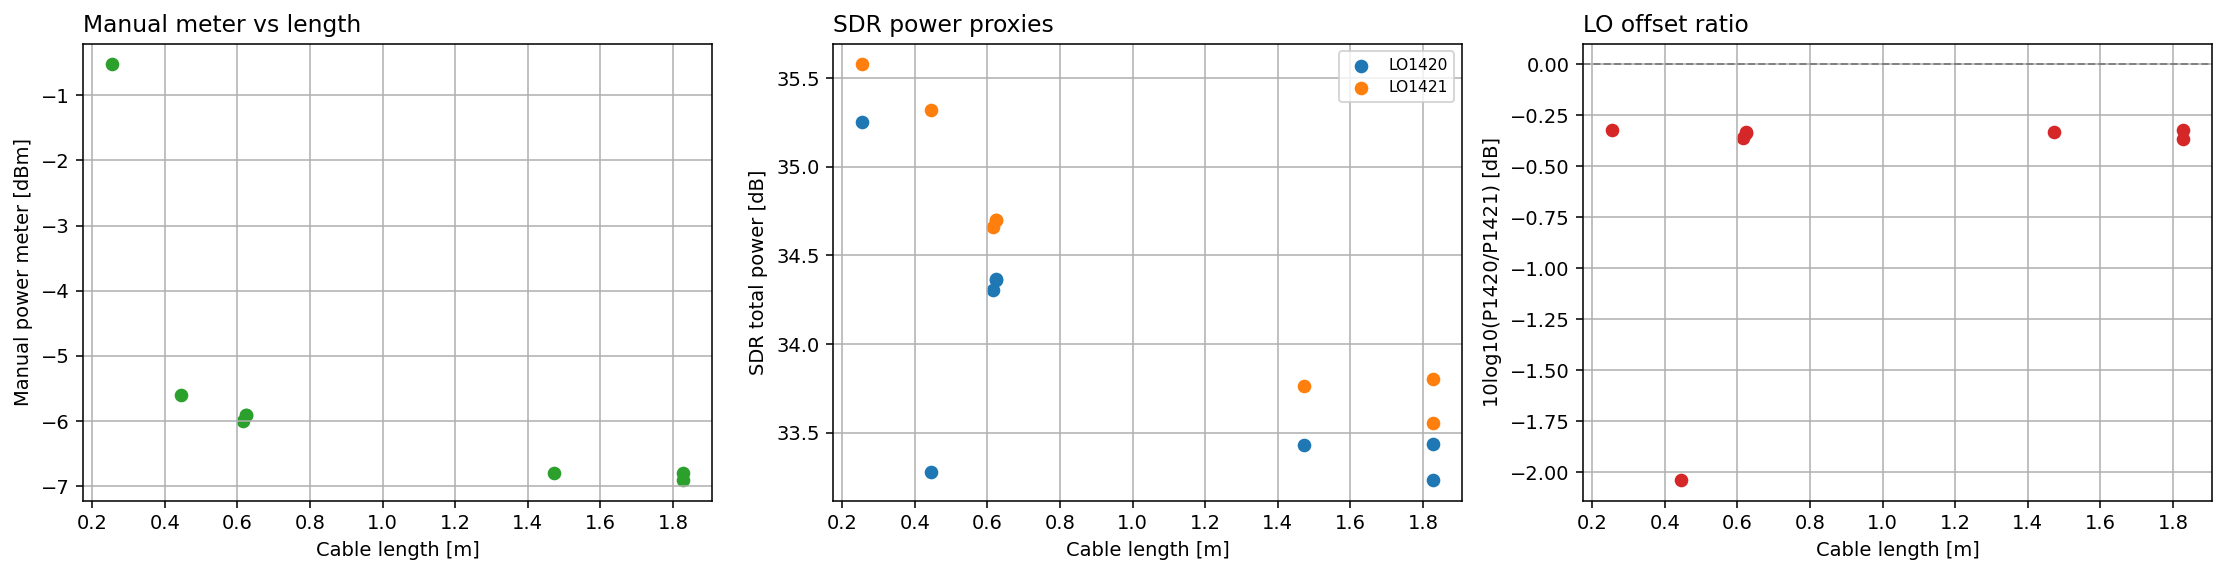

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), dpi=140)

axes[0].scatter(L, meter_dbm, color='C2')
axes[0].set_xlabel('Cable length [m]')
axes[0].set_ylabel('Manual power meter [dBm]')
axes[0].set_title('Manual meter vs length', loc='left')

axes[1].scatter(L, y1420_db, color='C0', label='LO1420')
axes[1].scatter(L, y1421_db, color='C1', label='LO1421')
axes[1].set_xlabel('Cable length [m]')
axes[1].set_ylabel('SDR total power [dB]')
axes[1].set_title('SDR power proxies', loc='left')
axes[1].legend(fontsize=8)

axes[2].scatter(L, ratio_db, color='C3')
axes[2].axhline(0, color='gray', lw=1, ls='--')
axes[2].set_xlabel('Cable length [m]')
axes[2].set_ylabel('10log10(P1420/P1421) [dB]')
axes[2].set_title('LO offset ratio', loc='left')

fig.tight_layout()
plt.show()


In [6]:
def fit_shared_linear(L: np.ndarray, y0: np.ndarray, y1: np.ndarray) -> dict:
    L = np.asarray(L, dtype=float)
    y0 = np.asarray(y0, dtype=float)
    y1 = np.asarray(y1, dtype=float)
    n = L.size

    y = np.concatenate([y0, y1])
    X = np.zeros((2*n, 3), dtype=float)
    X[:n, 0] = 1.0
    X[:n, 2] = -L
    X[n:, 1] = 1.0
    X[n:, 2] = -L

    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    B0, B1, alpha = beta
    yhat = X @ beta
    resid = y - yhat
    rss = float(np.sum(resid**2))
    n_obs = y.size
    dof = n_obs - beta.size
    sigma2 = rss / dof if dof > 0 else np.nan
    cov = sigma2 * np.linalg.inv(X.T @ X) if np.isfinite(sigma2) else np.full((3,3), np.nan)
    sig = np.sqrt(np.diag(cov))
    var_delta = cov[0,0] + cov[1,1] - 2*cov[0,1]
    sig_delta = np.sqrt(var_delta) if var_delta >= 0 else np.nan
    aic, bic = aic_bic_from_rss(rss, n_obs, 3)
    return {
        'B1420_db': float(B0),
        'B1421_db': float(B1),
        'alpha_db_per_m': float(alpha),
        'deltaB_db': float(B0 - B1),
        'sigma_B1420_db': float(sig[0]),
        'sigma_B1421_db': float(sig[1]),
        'sigma_alpha_db_per_m': float(sig[2]),
        'sigma_deltaB_db': float(sig_delta),
        'rss': rss,
        'rmse': float(np.sqrt(np.mean(resid**2))),
        'aic': aic,
        'bic': bic,
        'yhat': yhat,
        'residuals': resid,
    }


def fit_single_linear(L: np.ndarray, y: np.ndarray) -> dict:
    L = np.asarray(L, dtype=float)
    y = np.asarray(y, dtype=float)
    X = np.column_stack([np.ones_like(L), -L])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    B, alpha = beta
    yhat = X @ beta
    resid = y - yhat
    rss = float(np.sum(resid**2))
    n_obs = y.size
    dof = n_obs - beta.size
    sigma2 = rss / dof if dof > 0 else np.nan
    cov = sigma2 * np.linalg.inv(X.T @ X) if np.isfinite(sigma2) else np.full((2,2), np.nan)
    sig = np.sqrt(np.diag(cov))
    aic, bic = aic_bic_from_rss(rss, n_obs, 2)
    return {
        'B_db': float(B),
        'alpha_db_per_m': float(alpha),
        'sigma_B_db': float(sig[0]),
        'sigma_alpha_db_per_m': float(sig[1]),
        'rss': rss,
        'rmse': float(np.sqrt(np.mean(resid**2))),
        'aic': aic,
        'bic': bic,
        'yhat': yhat,
        'residuals': resid,
    }


def _shared_ripple_fit_at_k(L: np.ndarray, y0: np.ndarray, y1: np.ndarray, k: float):
    L = np.asarray(L, dtype=float)
    c = np.cos(k * L)
    s = np.sin(k * L)
    n = L.size

    # y0 = B0 - aL + C0 cos(kL) + D0 sin(kL)
    # y1 = B1 - aL + C1 cos(kL) + D1 sin(kL)
    X = np.zeros((2*n, 7), dtype=float)
    y = np.concatenate([y0, y1])

    X[:n, 0] = 1.0
    X[:n, 2] = -L
    X[:n, 3] = c
    X[:n, 4] = s

    X[n:, 1] = 1.0
    X[n:, 2] = -L
    X[n:, 5] = c
    X[n:, 6] = s

    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    yhat = X @ beta
    resid = y - yhat
    rss = float(np.sum(resid**2))
    return beta, yhat, resid, rss


def fit_shared_ripple(L: np.ndarray, y0: np.ndarray, y1: np.ndarray, k_grid: np.ndarray | None = None) -> dict:
    L = np.asarray(L, dtype=float)
    y0 = np.asarray(y0, dtype=float)
    y1 = np.asarray(y1, dtype=float)

    if k_grid is None:
        k_min = 2*np.pi / K_PERIOD_MAX_M
        k_max = 2*np.pi / K_PERIOD_MIN_M
        k_grid = np.linspace(k_min, k_max, K_GRID_N)

    rss_grid = np.full(k_grid.shape, np.nan, dtype=float)
    best = None

    for i, k in enumerate(k_grid):
        try:
            beta, yhat, resid, rss = _shared_ripple_fit_at_k(L, y0, y1, float(k))
        except np.linalg.LinAlgError:
            continue
        rss_grid[i] = rss
        if best is None or rss < best["rss"]:
            best = {"k": float(k), "beta": beta, "yhat": yhat, "resid": resid, "rss": float(rss)}

    if best is None:
        raise RuntimeError('Ripple fit failed for all k values.')

    B0, B1, alpha, C0, D0, C1, D1 = best["beta"]
    A0 = float(np.hypot(C0, D0))
    A1 = float(np.hypot(C1, D1))
    phi0 = float(np.arctan2(-D0, C0))
    phi1 = float(np.arctan2(-D1, C1))

    n_obs = 2 * L.size
    # Effective parameter count includes k search parameter.
    n_params_eff = 8
    dof = n_obs - n_params_eff
    sigma2 = best["rss"] / dof if dof > 0 else np.nan

    # Covariance for linear params at fixed k (k uncertainty via bootstrap).
    c = np.cos(best["k"] * L)
    s = np.sin(best["k"] * L)
    X = np.zeros((2*L.size, 7), dtype=float)
    X[:L.size, 0] = 1.0
    X[:L.size, 2] = -L
    X[:L.size, 3] = c
    X[:L.size, 4] = s
    X[L.size:, 1] = 1.0
    X[L.size:, 2] = -L
    X[L.size:, 5] = c
    X[L.size:, 6] = s
    cov_lin = sigma2 * np.linalg.inv(X.T @ X) if np.isfinite(sigma2) else np.full((7,7), np.nan)
    sigma_alpha = float(np.sqrt(cov_lin[2, 2])) if np.isfinite(cov_lin[2,2]) and cov_lin[2,2] >= 0 else np.nan

    aic, bic = aic_bic_from_rss(best["rss"], n_obs, n_params_eff)
    return {
        'B1420_db': float(B0),
        'B1421_db': float(B1),
        'alpha_db_per_m': float(alpha),
        'sigma_alpha_db_per_m': sigma_alpha,
        'k_rad_per_m': float(best['k']),
        'period_m': float(2*np.pi / best['k']),
        'A1420_db': A0,
        'A1421_db': A1,
        'phi1420_rad': phi0,
        'phi1421_rad': phi1,
        'deltaB_db': float(B0 - B1),
        'rss': float(best['rss']),
        'rmse': float(np.sqrt(np.mean(best['resid']**2))),
        'aic': aic,
        'bic': bic,
        'yhat': best['yhat'],
        'residuals': best['resid'],
        'k_grid': k_grid,
        'rss_grid': rss_grid,
    }


def fit_single_ripple(L: np.ndarray, y: np.ndarray, k_grid: np.ndarray | None = None) -> dict:
    L = np.asarray(L, dtype=float)
    y = np.asarray(y, dtype=float)
    if k_grid is None:
        k_min = 2*np.pi / K_PERIOD_MAX_M
        k_max = 2*np.pi / K_PERIOD_MIN_M
        k_grid = np.linspace(k_min, k_max, K_GRID_N)

    best = None
    rss_grid = np.full(k_grid.shape, np.nan, dtype=float)
    for i, k in enumerate(k_grid):
        c = np.cos(k * L)
        s = np.sin(k * L)
        X = np.column_stack([np.ones_like(L), -L, c, s])
        try:
            beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        except np.linalg.LinAlgError:
            continue
        yhat = X @ beta
        resid = y - yhat
        rss = float(np.sum(resid**2))
        rss_grid[i] = rss
        if best is None or rss < best["rss"]:
            best = {"k": float(k), "beta": beta, "yhat": yhat, "resid": resid, "rss": rss}
    if best is None:
        raise RuntimeError('Single ripple fit failed for all k.')
    B, alpha, C, D = best["beta"]
    A = float(np.hypot(C, D))
    phi = float(np.arctan2(-D, C))
    n_obs = y.size
    n_params_eff = 5
    aic, bic = aic_bic_from_rss(best["rss"], n_obs, n_params_eff)
    return {
        'B_db': float(B),
        'alpha_db_per_m': float(alpha),
        'k_rad_per_m': float(best['k']),
        'period_m': float(2*np.pi / best['k']),
        'A_db': A,
        'phi_rad': phi,
        'rss': float(best['rss']),
        'rmse': float(np.sqrt(np.mean(best['resid']**2))),
        'aic': aic,
        'bic': bic,
        'yhat': best['yhat'],
        'residuals': best['resid'],
        'k_grid': k_grid,
        'rss_grid': rss_grid,
    }


def bootstrap_linear_shared(L, y0, y1, n_boot=BOOTSTRAP_LINEAR_N, seed=BOOTSTRAP_SEED):
    rng = np.random.default_rng(seed)
    n = len(L)
    alpha = []
    delta = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        Ls = L[idx]
        if np.unique(Ls).size < 2:
            continue
        f = fit_shared_linear(Ls, y0[idx], y1[idx])
        alpha.append(f["alpha_db_per_m"])
        delta.append(f["deltaB_db"])
    return np.array(alpha, float), np.array(delta, float)


def bootstrap_ripple_shared(L, y0, y1, k_grid, n_boot=BOOTSTRAP_RIPPLE_N, seed=BOOTSTRAP_SEED):
    rng = np.random.default_rng(seed)
    n = len(L)
    alpha = []
    kvals = []
    fail = 0
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        Ls = L[idx]
        if np.unique(Ls).size < 2:
            fail += 1
            continue
        try:
            f = fit_shared_ripple(Ls, y0[idx], y1[idx], k_grid=k_grid)
        except Exception:
            fail += 1
            continue
        alpha.append(f["alpha_db_per_m"])
        kvals.append(f["k_rad_per_m"])
    return np.array(alpha, float), np.array(kvals, float), fail


def bootstrap_linear_single(L, y, n_boot=BOOTSTRAP_LINEAR_N, seed=BOOTSTRAP_SEED):
    rng = np.random.default_rng(seed)
    n = len(L)
    alpha = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        Ls = L[idx]
        if np.unique(Ls).size < 2:
            continue
        f = fit_single_linear(Ls, y[idx])
        alpha.append(f["alpha_db_per_m"])
    return np.array(alpha, float)


In [7]:
k_grid = np.linspace(2*np.pi / K_PERIOD_MAX_M, 2*np.pi / K_PERIOD_MIN_M, K_GRID_N)

fit_lin_sdr = fit_shared_linear(L, y1420_db, y1421_db)
fit_rip_sdr = fit_shared_ripple(L, y1420_db, y1421_db, k_grid=k_grid)

fit_lin_meter = fit_single_linear(L, meter_dbm)
fit_rip_meter = fit_single_ripple(L, meter_dbm, k_grid=k_grid)

alpha_lin_bs, delta_lin_bs = bootstrap_linear_shared(L, y1420_db, y1421_db)
alpha_rip_bs, k_rip_bs, n_fail_rip_bs = bootstrap_ripple_shared(L, y1420_db, y1421_db, k_grid=k_grid)
alpha_meter_bs = bootstrap_linear_single(L, meter_dbm)

print("=== Fit quality (SDR) ===")
print(f"Linear : RMSE={fit_lin_sdr['rmse']:.4f} dB, AIC={fit_lin_sdr['aic']:.3f}, BIC={fit_lin_sdr['bic']:.3f}")
print(f"Ripple : RMSE={fit_rip_sdr['rmse']:.4f} dB, AIC={fit_rip_sdr['aic']:.3f}, BIC={fit_rip_sdr['bic']:.3f}")

print("=== Fit quality (meter) ===")
print(f"Linear : RMSE={fit_lin_meter['rmse']:.4f} dB, AIC={fit_lin_meter['aic']:.3f}, BIC={fit_lin_meter['bic']:.3f}")
print(f"Ripple : RMSE={fit_rip_meter['rmse']:.4f} dB, AIC={fit_rip_meter['aic']:.3f}, BIC={fit_rip_meter['bic']:.3f}")

print("=== SDR parameter estimates ===")
print(f"Linear alpha = {fit_lin_sdr['alpha_db_per_m']:.6f} +/- {fit_lin_sdr['sigma_alpha_db_per_m']:.6f} dB/m")
print(f"Ripple alpha = {fit_rip_sdr['alpha_db_per_m']:.6f} +/- {fit_rip_sdr['sigma_alpha_db_per_m']:.6f} dB/m (fixed-k covariance)")
print(f"Ripple k = {fit_rip_sdr['k_rad_per_m']:.6f} rad/m  (period={fit_rip_sdr['period_m']:.4f} m)")
print(f"Ripple A1420={fit_rip_sdr['A1420_db']:.4f} dB, A1421={fit_rip_sdr['A1421_db']:.4f} dB")

print("=== Bootstrap counts ===")
print(f"Linear SDR bootstrap valid: {alpha_lin_bs.size}/{BOOTSTRAP_LINEAR_N}")
print(f"Ripple SDR bootstrap valid: {alpha_rip_bs.size}/{BOOTSTRAP_RIPPLE_N} (failed {n_fail_rip_bs})")
print(f"Linear meter bootstrap valid: {alpha_meter_bs.size}/{BOOTSTRAP_LINEAR_N}")


=== Fit quality (SDR) ===
Linear : RMSE=0.3788 dB, AIC=-25.067, BIC=-22.749
Ripple : RMSE=0.1245 dB, AIC=-50.667, BIC=-44.486
=== Fit quality (meter) ===
Linear : RMSE=1.5000 dB, AIC=10.487, BIC=10.646
Ripple : RMSE=0.0298 dB, AIC=-46.207, BIC=-45.809
=== SDR parameter estimates ===
Linear alpha = 0.951176 +/- 0.174973 dB/m
Ripple alpha = 1.355546 +/- 0.104369 dB/m (fixed-k covariance)
Ripple k = 7.803548 rad/m  (period=0.8052 m)
Ripple A1420=1.4809 dB, A1421=0.2517 dB
=== Bootstrap counts ===
Linear SDR bootstrap valid: 10000/10000
Ripple SDR bootstrap valid: 1000/1000 (failed 0)
Linear meter bootstrap valid: 10000/10000


In [8]:
def q68_95(samples: np.ndarray):
    q16, q50, q84 = safe_quantiles(samples, (0.16, 0.5, 0.84))
    q025, q975 = safe_quantiles(samples, (0.025, 0.975))
    return (q16, q50, q84), (q025, q975)

(a16, a50, a84), (a025, a975) = q68_95(alpha_lin_bs)
(ar16, ar50, ar84), (ar025, ar975) = q68_95(alpha_rip_bs)
(k16, k50, k84), (k025, k975) = q68_95(k_rip_bs)
(m16, m50, m84), (m025, m975) = q68_95(alpha_meter_bs)

lambda_eff = 4*np.pi / fit_rip_sdr["k_rad_per_m"]
vf_est = siggen_freq_hz * lambda_eff / C_LIGHT

print("=== Uncertainty summary ===")
print(f"Linear SDR alpha median [16,84]: {a50:.6f} [{a16:.6f}, {a84:.6f}] dB/m")
print(f"Linear SDR alpha 95% CI      : [{a025:.6f}, {a975:.6f}] dB/m")
print(f"Ripple SDR alpha median [16,84]: {ar50:.6f} [{ar16:.6f}, {ar84:.6f}] dB/m")
print(f"Ripple SDR alpha 95% CI       : [{ar025:.6f}, {ar975:.6f}] dB/m")
print(f"Ripple k median [16,84]       : {k50:.6f} [{k16:.6f}, {k84:.6f}] rad/m")
print(f"Ripple k 95% CI               : [{k025:.6f}, {k975:.6f}] rad/m")
print(f"Meter linear alpha median [16,84]: {m50:.6f} [{m16:.6f}, {m84:.6f}] dB/m")
print(f"Meter linear alpha 95% CI       : [{m025:.6f}, {m975:.6f}] dB/m")

print("=== Reflection physical scale (from ripple k) ===")
print(f"lambda_eff = {lambda_eff:.6f} m")
print(f"VF_est     = {vf_est:.6f}")
print("(Model-dependent estimate for this splitter+open-stub topology.)")

print("=== -13 dB attenuator correction (intercepts only) ===")
print(f"Linear B1420 at splitter reference: {fit_lin_sdr['B1420_db'] + ATTENUATOR_DB:.6f} dB")
print(f"Linear B1421 at splitter reference: {fit_lin_sdr['B1421_db'] + ATTENUATOR_DB:.6f} dB")
print("Attenuation slope alpha is unchanged by a fixed attenuator.")


=== Uncertainty summary ===
Linear SDR alpha median [16,84]: 0.954838 [0.771747, 1.139180] dB/m
Linear SDR alpha 95% CI      : [0.618877, 1.459224] dB/m
Ripple SDR alpha median [16,84]: 1.142350 [0.701720, 1.348586] dB/m
Ripple SDR alpha 95% CI       : [-16.247540, 2.326725] dB/m
Ripple k median [16,84]       : 11.964320 [7.387471, 20.701940] rad/m
Ripple k 95% CI               : [0.314159, 29.023483] rad/m
Meter linear alpha median [16,84]: 2.140643 [0.842737, 3.175018] dB/m
Meter linear alpha 95% CI       : [0.755465, 5.042596] dB/m
=== Reflection physical scale (from ripple k) ===
lambda_eff = 1.610341 m
VF_est     = 7.629735
(Model-dependent estimate for this splitter+open-stub topology.)
=== -13 dB attenuator correction (intercepts only) ===
Linear B1420 at splitter reference: 47.873637 dB
Linear B1421 at splitter reference: 48.424423 dB
Attenuation slope alpha is unchanged by a fixed attenuator.


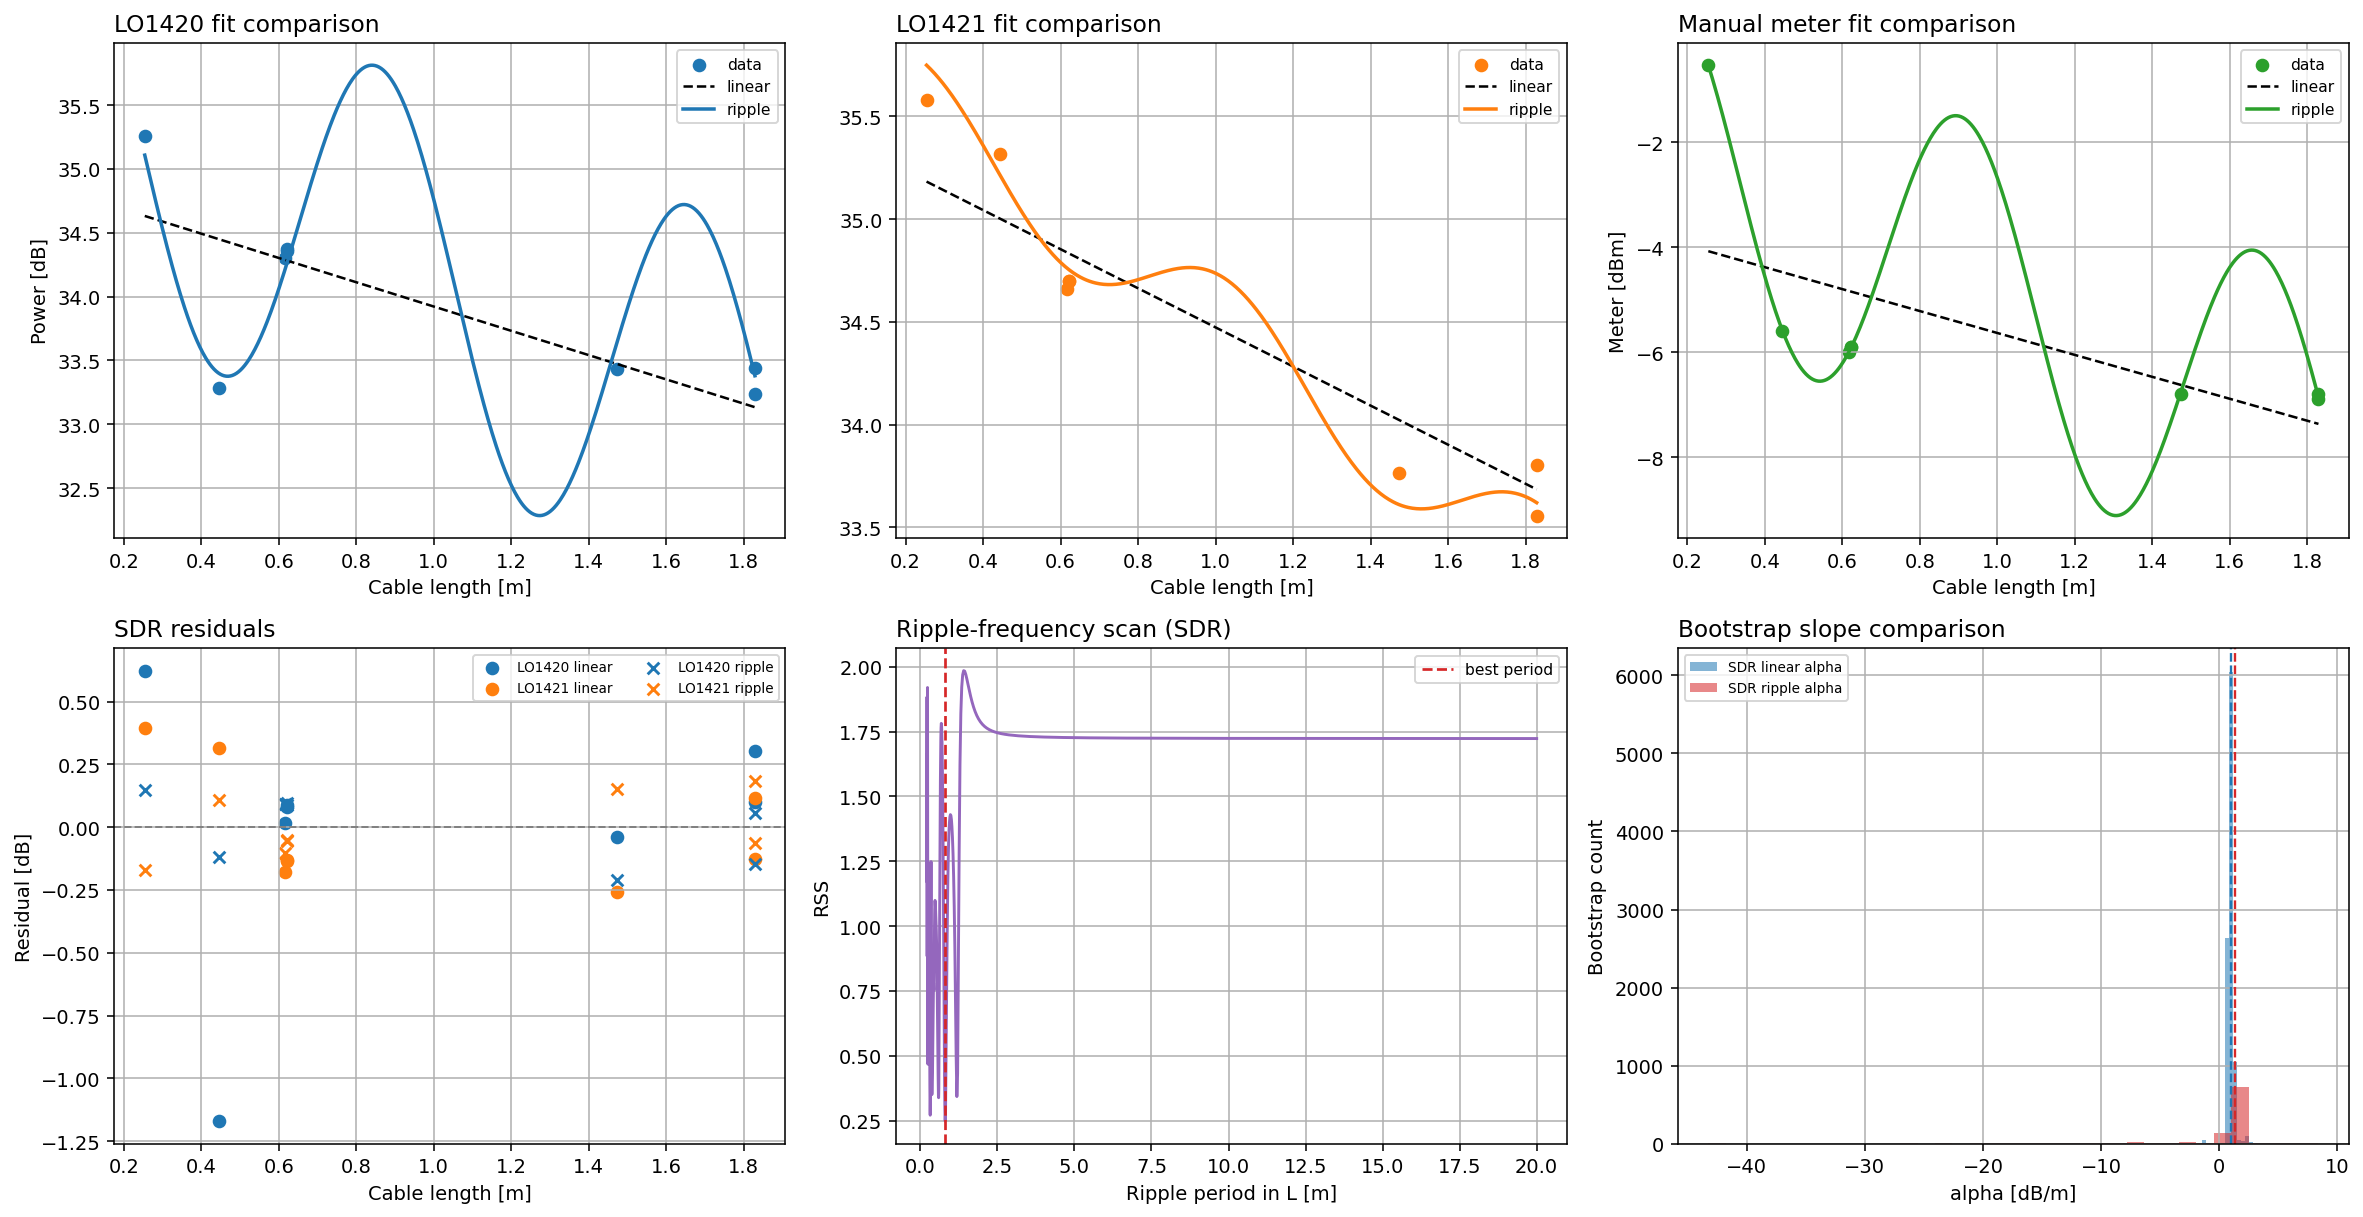

In [9]:
L_line = np.linspace(float(L.min()), float(L.max()), 600)

# Linear predictions
y0_lin = fit_lin_sdr["B1420_db"] - fit_lin_sdr["alpha_db_per_m"] * L_line
y1_lin = fit_lin_sdr["B1421_db"] - fit_lin_sdr["alpha_db_per_m"] * L_line
ym_lin = fit_lin_meter["B_db"] - fit_lin_meter["alpha_db_per_m"] * L_line

# Ripple predictions
y0_rip = fit_rip_sdr["B1420_db"] - fit_rip_sdr["alpha_db_per_m"] * L_line + fit_rip_sdr["A1420_db"] * np.cos(fit_rip_sdr["k_rad_per_m"] * L_line + fit_rip_sdr["phi1420_rad"])
y1_rip = fit_rip_sdr["B1421_db"] - fit_rip_sdr["alpha_db_per_m"] * L_line + fit_rip_sdr["A1421_db"] * np.cos(fit_rip_sdr["k_rad_per_m"] * L_line + fit_rip_sdr["phi1421_rad"])
ym_rip = fit_rip_meter["B_db"] - fit_rip_meter["alpha_db_per_m"] * L_line + fit_rip_meter["A_db"] * np.cos(fit_rip_meter["k_rad_per_m"] * L_line + fit_rip_meter["phi_rad"])

fig, axes = plt.subplots(2, 3, figsize=(17, 8.8), dpi=140)

# SDR LO1420
axes[0,0].scatter(L, y1420_db, color='C0', label='data')
axes[0,0].plot(L_line, y0_lin, color='k', lw=1.3, ls='--', label='linear')
axes[0,0].plot(L_line, y0_rip, color='C0', lw=1.8, label='ripple')
axes[0,0].set_title('LO1420 fit comparison', loc='left')
axes[0,0].set_xlabel('Cable length [m]')
axes[0,0].set_ylabel('Power [dB]')
axes[0,0].legend(fontsize=8)

# SDR LO1421
axes[0,1].scatter(L, y1421_db, color='C1', label='data')
axes[0,1].plot(L_line, y1_lin, color='k', lw=1.3, ls='--', label='linear')
axes[0,1].plot(L_line, y1_rip, color='C1', lw=1.8, label='ripple')
axes[0,1].set_title('LO1421 fit comparison', loc='left')
axes[0,1].set_xlabel('Cable length [m]')
axes[0,1].legend(fontsize=8)

# Meter
axes[0,2].scatter(L, meter_dbm, color='C2', label='data')
axes[0,2].plot(L_line, ym_lin, color='k', lw=1.3, ls='--', label='linear')
axes[0,2].plot(L_line, ym_rip, color='C2', lw=1.8, label='ripple')
axes[0,2].set_title('Manual meter fit comparison', loc='left')
axes[0,2].set_xlabel('Cable length [m]')
axes[0,2].set_ylabel('Meter [dBm]')
axes[0,2].legend(fontsize=8)

# Residuals SDR
res0_lin = y1420_db - (fit_lin_sdr["B1420_db"] - fit_lin_sdr["alpha_db_per_m"] * L)
res1_lin = y1421_db - (fit_lin_sdr["B1421_db"] - fit_lin_sdr["alpha_db_per_m"] * L)
res0_rip = y1420_db - (fit_rip_sdr["B1420_db"] - fit_rip_sdr["alpha_db_per_m"] * L + fit_rip_sdr["A1420_db"] * np.cos(fit_rip_sdr["k_rad_per_m"] * L + fit_rip_sdr["phi1420_rad"]))
res1_rip = y1421_db - (fit_rip_sdr["B1421_db"] - fit_rip_sdr["alpha_db_per_m"] * L + fit_rip_sdr["A1421_db"] * np.cos(fit_rip_sdr["k_rad_per_m"] * L + fit_rip_sdr["phi1421_rad"]))

axes[1,0].axhline(0, color='gray', ls='--', lw=1)
axes[1,0].scatter(L, res0_lin, color='C0', marker='o', label='LO1420 linear')
axes[1,0].scatter(L, res1_lin, color='C1', marker='o', label='LO1421 linear')
axes[1,0].scatter(L, res0_rip, color='C0', marker='x', label='LO1420 ripple')
axes[1,0].scatter(L, res1_rip, color='C1', marker='x', label='LO1421 ripple')
axes[1,0].set_title('SDR residuals', loc='left')
axes[1,0].set_xlabel('Cable length [m]')
axes[1,0].set_ylabel('Residual [dB]')
axes[1,0].legend(fontsize=7, ncol=2)

# k profile
period_grid = 2*np.pi / fit_rip_sdr["k_grid"]
axes[1,1].plot(period_grid, fit_rip_sdr['rss_grid'], color='C4')
axes[1,1].axvline(fit_rip_sdr['period_m'], color='C3', ls='--', lw=1.4, label='best period')
axes[1,1].set_xlabel('Ripple period in L [m]')
axes[1,1].set_ylabel('RSS')
axes[1,1].set_title('Ripple-frequency scan (SDR)', loc='left')
axes[1,1].legend(fontsize=8)

# Bootstrap alpha comparison
axes[1,2].hist(alpha_lin_bs, bins=35, alpha=0.55, color='C0', label='SDR linear alpha')
axes[1,2].hist(alpha_rip_bs, bins=35, alpha=0.55, color='C3', label='SDR ripple alpha')
axes[1,2].axvline(fit_lin_sdr['alpha_db_per_m'], color='C0', ls='--', lw=1.2)
axes[1,2].axvline(fit_rip_sdr['alpha_db_per_m'], color='C3', ls='--', lw=1.2)
axes[1,2].set_xlabel('alpha [dB/m]')
axes[1,2].set_ylabel('Bootstrap count')
axes[1,2].set_title('Bootstrap slope comparison', loc='left')
axes[1,2].legend(fontsize=7)

fig.tight_layout()
plt.show()


In [10]:
def ci_str(lo, hi):
    return f'[{lo:.6f}, {hi:.6f}]'

(da16, da50, da84), (da025, da975) = q68_95(delta_lin_bs)

print("=== Final report summary ===")
print(f'Sets used after exclusion: {len(rows)}')
print(f'Excluded anomaly lengths [m]: {EXCLUDE_LENGTHS_M} +/- {EXCLUDE_LENGTH_TOL_M}')
print()
print("SDR (linear model):")
print(f"  y1420 = -{fit_lin_sdr['alpha_db_per_m']:.6f} x + {fit_lin_sdr['B1420_db']:.6f}")
print(f"  y1421 = -{fit_lin_sdr['alpha_db_per_m']:.6f} x + {fit_lin_sdr['B1421_db']:.6f}")
print(f"  alpha OLS = {fit_lin_sdr['alpha_db_per_m']:.6f} +/- {fit_lin_sdr['sigma_alpha_db_per_m']:.6f} dB/m")
print(f"  alpha bootstrap 95% CI = {ci_str(a025, a975)} dB/m")
print(f"  deltaB OLS = {fit_lin_sdr['deltaB_db']:.6f} +/- {fit_lin_sdr['sigma_deltaB_db']:.6f} dB")
print(f"  deltaB bootstrap 95% CI = {ci_str(da025, da975)} dB")
print()
print("SDR (ripple model):")
print(f"  alpha = {fit_rip_sdr['alpha_db_per_m']:.6f} dB/m")
print(f"  alpha bootstrap 95% CI = {ci_str(ar025, ar975)} dB/m")
print(f"  k = {fit_rip_sdr['k_rad_per_m']:.6f} rad/m  (period={fit_rip_sdr['period_m']:.6f} m)")
print(f"  k bootstrap 95% CI = {ci_str(k025, k975)} rad/m")
print(f"  A1420={fit_rip_sdr['A1420_db']:.4f} dB, A1421={fit_rip_sdr['A1421_db']:.4f} dB")
print()
print("Manual meter (linear model):")
print(f"  y_meter = -{fit_lin_meter['alpha_db_per_m']:.6f} x + {fit_lin_meter['B_db']:.6f}")
print(f"  alpha OLS = {fit_lin_meter['alpha_db_per_m']:.6f} +/- {fit_lin_meter['sigma_alpha_db_per_m']:.6f} dB/m")
print(f"  alpha bootstrap 95% CI = {ci_str(m025, m975)} dB/m")
print()
print("Model comparison (AIC/BIC, lower is better):")
print(f"  SDR linear  : AIC={fit_lin_sdr['aic']:.3f}, BIC={fit_lin_sdr['bic']:.3f}")
print(f"  SDR ripple  : AIC={fit_rip_sdr['aic']:.3f}, BIC={fit_rip_sdr['bic']:.3f}")
print(f"  Meter linear: AIC={fit_lin_meter['aic']:.3f}, BIC={fit_lin_meter['bic']:.3f}")
print(f"  Meter ripple: AIC={fit_rip_meter['aic']:.3f}, BIC={fit_rip_meter['bic']:.3f}")
print()
print("-13 dB attenuator note (SDR intercepts only):")
print(f"  corrected c1420 = {fit_lin_sdr['B1420_db'] + ATTENUATOR_DB:.6f}")
print(f"  corrected c1421 = {fit_lin_sdr['B1421_db'] + ATTENUATOR_DB:.6f}")
print('  slopes (m) are unchanged by fixed attenuation.')


=== Final report summary ===
Sets used after exclusion: 8
Excluded anomaly lengths [m]: [7.9248] +/- 0.05

SDR (linear model):
  y1420 = -0.951176 x + 34.873637
  y1421 = -0.951176 x + 35.424423
  alpha OLS = 0.951176 +/- 0.174973 dB/m
  alpha bootstrap 95% CI = [0.618877, 1.459224] dB/m
  deltaB OLS = -0.550785 +/- 0.210100 dB
  deltaB bootstrap 95% CI = [-0.978442, -0.330536] dB

SDR (ripple model):
  alpha = 1.355546 dB/m
  alpha bootstrap 95% CI = [-16.247540, 2.326725] dB/m
  k = 7.803548 rad/m  (period=0.805170 m)
  k bootstrap 95% CI = [0.314159, 29.023483] rad/m
  A1420=1.4809 dB, A1421=0.2517 dB

Manual meter (linear model):
  y_meter = -2.090247 x + -3.544539
  alpha OLS = 2.090247 +/- 1.019948 dB/m
  alpha bootstrap 95% CI = [0.755465, 5.042596] dB/m

Model comparison (AIC/BIC, lower is better):
  SDR linear  : AIC=-25.067, BIC=-22.749
  SDR ripple  : AIC=-50.667, BIC=-44.486
  Meter linear: AIC=10.487, BIC=10.646
  Meter ripple: AIC=-46.207, BIC=-45.809

-13 dB attenuator n

## Notes
- This dataset is small; ripple-parameter intervals are sensitive to resampling and k-grid limits.
- `VF_est` from ripple period is model-dependent for this splitter + open-stub topology.
- If you want tighter uncertainty, add more lengths in the 0.2-2.0 m regime and repeated points at each length.
